**Predictive Analysis**

**Goal**
Predict **6-month cardiac patient readmission** with one strong, explainable model: **HistGradientBoostingClassifier**.

This notebook includes preprocessing, train/test validation, cross-validation, ROC-AUC, precision/recall/F1, confusion matrix, ROC and Precision-Recall curves, permutation feature importance, predicted probabilities, risk groups, and presentation-ready conclusions.

**1. Import Libraries**

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay
)

pd.set_option("display.max_columns", 200)


**2. Load Cleaned Data**

In [13]:
#Read the CSV from the data folder
df = pd.read_csv("../data/final/Team6_PyForce_cleaned_data.csv")


**3. Prediction Question**
**Which cardiac patients are more likely to be readmitted within 6 months?**

`0 = not readmitted`, `1 = readmitted`.

In [14]:
TARGET = "re_admission_within_6_months"

# Outcome columns that should not be used as predictors
outcome_columns = [
    "re_admission_within_28_days",
    "re_admission_within_3_months",
    "re_admission_within_6_months",
    "death_within_28_days",
    "death_within_3_months",
    "death_within_6_months"
]

# Future information / target leakage columns
leakage_columns = [
    "time_to_emergency_department_within_6_months",
    "return_to_emergency_department_within_6_months",
    "readmission_time_days_from_admission"
]

# Patient identifier columns
identifier_columns = [
    "patient_id",
    "patientid",
    "patient_ID",
    "id",
    "ID"
]

# Combine all columns that should be excluded
drop_columns = [
    col for col in
    outcome_columns + leakage_columns + identifier_columns
    if col in df.columns
]

# Create predictors and target
X = df.drop(columns=drop_columns)

y = df[TARGET].copy()

print("Excluded columns:")
for col in drop_columns:
    print("-", col)

print("\nNumber of predictor columns:", X.shape[1])

Excluded columns:
- re_admission_within_28_days
- re_admission_within_3_months
- re_admission_within_6_months
- death_within_28_days
- death_within_3_months
- death_within_6_months
- time_to_emergency_department_within_6_months
- return_to_emergency_department_within_6_months
- readmission_time_days_from_admission
- patient_id

Number of predictor columns: 161


**4. Target Distribution**

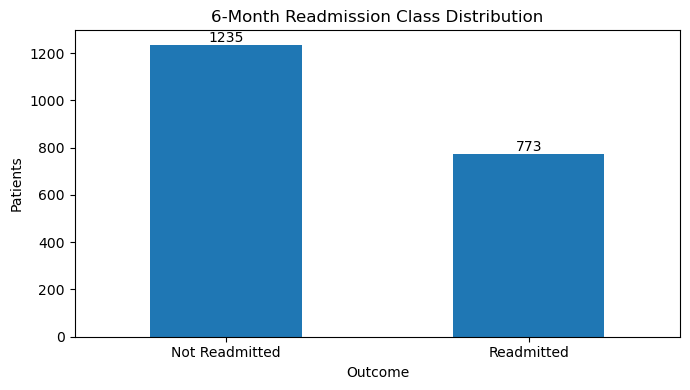

In [15]:
counts = y.value_counts().sort_index()
ax = counts.plot(kind="bar", figsize=(7,4))
ax.set_xticklabels(["Not Readmitted" if x==0 else "Readmitted" if x==1 else str(x)
                    for x in counts.index], rotation=0)
plt.title("6-Month Readmission Class Distribution")
plt.xlabel("Outcome")
plt.ylabel("Patients")
for p in ax.patches:
    ax.annotate(str(int(p.get_height())),
                (p.get_x()+p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.tight_layout()
plt.show()


**5. Missing Values — Top 20 Features**

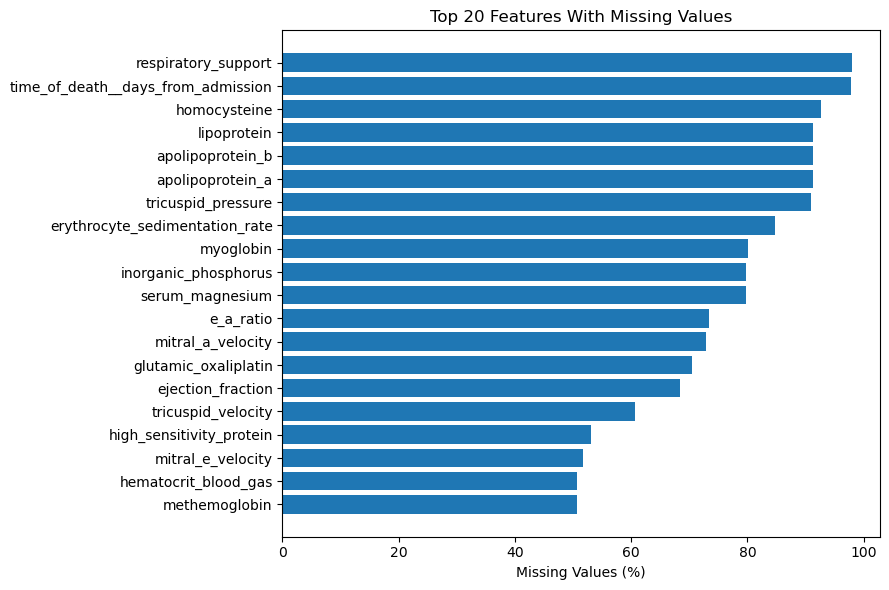

In [16]:
missing = X.isna().mean().mul(100).sort_values(ascending=False)
missing = missing[missing > 0].head(20)
if len(missing):
    plt.figure(figsize=(9,6))
    plt.barh(missing.index[::-1], missing.values[::-1])
    plt.xlabel("Missing Values (%)")
    plt.title("Top 20 Features With Missing Values")
    plt.tight_layout()
    plt.show()
else:
    print("No missing predictor values.")


**6. Preprocessing**
Numeric missing values use the median. Categorical missing values use the most frequent value, followed by one-hot encoding.

In [17]:
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, numeric_features),
    ("cat", categorical_pipe, categorical_features)
])

print("Numeric:", len(numeric_features))
print("Categorical:", len(categorical_features))


Numeric: 145
Categorical: 16


**7. Train/Test Split — 80% / 20%**

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print("Training:", len(X_train))
print("Testing:", len(X_test))


Training: 1606
Testing: 402


**8. Final Model — HistGradientBoostingClassifier**

In [19]:
model = Pipeline([
    ("prep", preprocessor),
    ("model", HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_depth=6,
        max_iter=300,
        l2_regularization=1.0,
        random_state=42
    ))
])

model.fit(X_train, y_train)
print("Training complete.")


Training complete.


**9. Predict Unseen Test Patients**

In [20]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]


**10. Confusion Matrix**

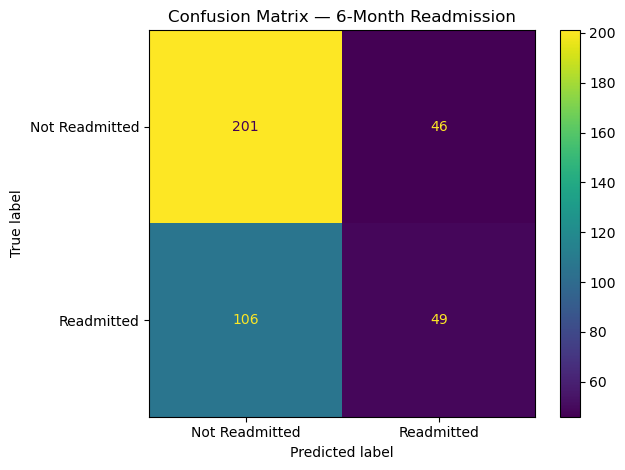

In [21]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["Not Readmitted","Readmitted"]
)
plt.title("Confusion Matrix — 6-Month Readmission")
plt.tight_layout()
plt.show()


**11. Top 20 Predictive Features — Permutation Importance**

This uses the **original `X_test.columns`**, which fixes the earlier feature-length mismatch.

A larger positive value means shuffling that feature caused a larger decrease in test ROC-AUC.

,Feature,Importance
Rank,,
1,hf_type,0.021000
2,mitral_e_velocity,0.018378
3,mitral_a_velocity,0.010976
4,death_recorded,0.009482
5,glomerular_filtration_rate,0.008891
6,activated_partial_thromboplastin_time,0.007998
7,lymphocyte_count,0.006269
8,albumin,0.005449
9,discharge_day,0.004952


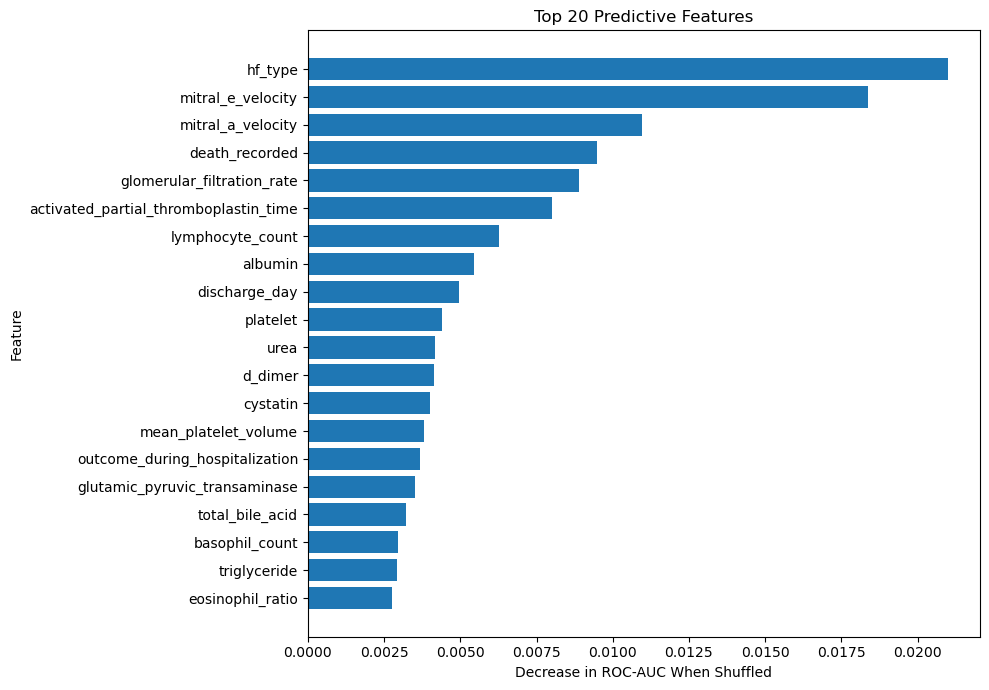

In [23]:
# Calculate permutation importance
perm = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    scoring="roc_auc",
    n_jobs=-1
)

# Create Top 20 Feature Importance table
importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm.importances_mean
}).sort_values(
    "Importance",
    ascending=False
).head(20).reset_index(drop=True)

# Change index to Rank 1-20
importance.index = importance.index + 1
importance.index.name = "Rank"

# Display clean table
display(importance)

# Sort smallest to largest for horizontal bar chart
p = importance.sort_values("Importance", ascending=True)

# Create visualization
plt.figure(figsize=(10, 7))

plt.barh(
    p["Feature"],
    p["Importance"]
)

plt.xlabel("Decrease in ROC-AUC When Shuffled")
plt.ylabel("Feature")
plt.title("Top 20 Predictive Features")

plt.tight_layout()
plt.show()

**Interpretation:** These variables are the ones the fitted model relies on most for prediction. Predictive importance does **not** prove causation.

**12. Risk Groups**

For a simple presentation:
- **Low Risk:** < 30%
- **Medium Risk:** 30% to < 70%
- **High Risk:** ≥ 70%

These are demonstration thresholds, not clinical cutoffs.

,Patients
Risk_Group,
Low Risk,187
Medium Risk,182
High Risk,33


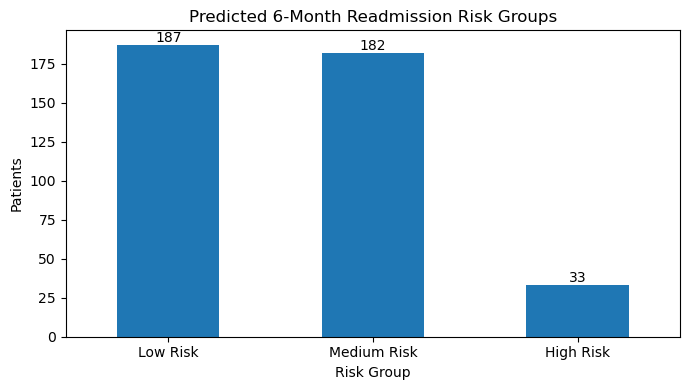

In [24]:
risk = pd.DataFrame({
    "Actual_Readmission": np.asarray(y_test),
    "Predicted_Probability": y_prob
})

risk["Risk_Group"] = pd.cut(
    risk["Predicted_Probability"],
    [-np.inf,0.30,0.70,np.inf],
    labels=["Low Risk","Medium Risk","High Risk"],
    right=False
)

order = ["Low Risk","Medium Risk","High Risk"]
risk_counts = risk["Risk_Group"].value_counts().reindex(order,fill_value=0)
display(risk_counts.to_frame("Patients"))

ax = risk_counts.plot(kind="bar",figsize=(7,4))
plt.title("Predicted 6-Month Readmission Risk Groups")
plt.xlabel("Risk Group")
plt.ylabel("Patients")
plt.xticks(rotation=0)
for p in ax.patches:
    ax.annotate(str(int(p.get_height())),
                (p.get_x()+p.get_width()/2,p.get_height()),
                ha="center",va="bottom")
plt.tight_layout()
plt.show()


**13. Actual Readmission Rate Within Each Predicted Risk Group**

,Patients,Actual_Readmission_Rate,Average_Predicted_Risk
Risk_Group,,,
Low Risk,187,27.81,15.12
Medium Risk,182,43.96,46.25
High Risk,33,69.70,79.23


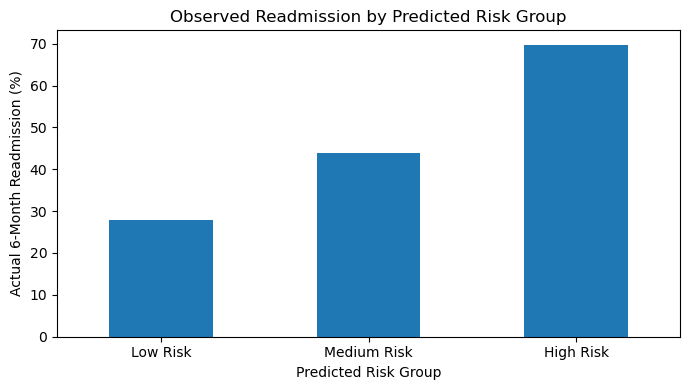

In [25]:
risk_summary = risk.groupby("Risk_Group", observed=True).agg(
    Patients=("Actual_Readmission","size"),
    Actual_Readmission_Rate=("Actual_Readmission","mean"),
    Average_Predicted_Risk=("Predicted_Probability","mean")
).reindex(order)

risk_summary["Actual_Readmission_Rate"] *= 100
risk_summary["Average_Predicted_Risk"] *= 100
display(risk_summary.round(2))

risk_summary["Actual_Readmission_Rate"].plot(kind="bar",figsize=(7,4))
plt.ylabel("Actual 6-Month Readmission (%)")
plt.xlabel("Predicted Risk Group")
plt.title("Observed Readmission by Predicted Risk Group")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### 14. Final Conclusion ###

### What did we do?
We built a machine-learning model to estimate **which cardiac patients are more likely to be readmitted within six months**.

### Why HistGradientBoosting?
Cardiac outcomes can depend on complicated and nonlinear relationships among demographics, cardiac severity, comorbidities, responsiveness, laboratory values, medications and other patient characteristics. Gradient boosting can learn these relationships without requiring a simple straight-line relationship.

### What did we learn?
Permutation importance identifies which original patient variables contribute most to the model's predictive performance. These are predictive relationships, not proof of medical causation.

### Business value
The predicted probability can organize patients into demonstration **Low, Medium and High Risk** groups. This creates the bridge to prescriptive analytics: higher-risk groups can be considered for closer review, stronger discharge planning, follow-up, medication review or additional monitoring.
